In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as tck
import matplotlib.pyplot as plt
from lmfit.models import SineModel, ConstantModel

In [2]:
# data for low power decoy state
# files are globbed and fit to extract visibility and thus fidelity
data_dir = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_no_phase_offset')
data_dir_phase = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                  '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_half_pi_phase_offset')
two_pulse_offres = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                    '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_half_pi_phase_offset/two_pulse_phase_shifted_offres.txt')
one_pulse_echo = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                    '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_no_phase_offset/one_pulse_3_00pi.txt')
# data for high power decoy state
# there are four discrete files used for visibility estimation, and an offres file for estimating mean photon number
data_min_high = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                 '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_high_power/two_pulse_42dB_0_02pi.txt')
data_max_high = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                 '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_high_power/two_pulse_42dB_1_02pi.txt')
data_min_phase_high = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                       '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_high_power/two_pulse_phase_shifted_42dB_1_44pi.txt')
data_max_phase_high = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                       '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_high_power/two_pulse_phase_shifted_42dB_0_44pi.txt')
two_pulse_offres_high = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                         '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_high_power/two_pulse_42dB_offres.txt')

In [3]:
interference_window = (1.97-0.05, 1.97+0.05)

# plotting params
mpl.rcParams.update({'font.sans-serif': 'Helvetica',
                     'font.size': 12})
xlim = (1.97-0.2, 1.97+0.2)  # for interference
xlim_input = (0.9, 1.2)
color_no_phase = 'cornflowerblue'
color_phase = 'coral'

In [4]:
# read low power data and fit
# gather data
storage_files = glob.glob('two_pulse_*pi.txt', root_dir=data_dir)
storage_files.sort()
storage_files_phase = glob.glob('two_pulse_*pi.txt', root_dir=data_dir_phase)
storage_files_phase.sort()

dfs = []
all_phases = []
all_interference_counts = []
for file in storage_files:
    file_path = os.path.join(data_dir, file)
    df = pd.read_csv(file_path, sep='\t')
    dfs.append(df)

    file_parts = file.split('_')
    pi_fraction = float(file_parts[2]) + (float(file_parts[3][:2])/100)
    all_phases.append(pi_fraction)

    # gather relevant data
    time = df['time(ps)']
    time /= 1e6  # convert to us
    counts = df['counts']
    int_idx = np.where(np.logical_and(time > interference_window[0], time < interference_window[1]))[0]
    interference_counts = np.sum(counts[int_idx])
    all_interference_counts.append(interference_counts)

dfs_phase = []
all_phases_phase = []
all_interference_counts_phase = []
for file in storage_files_phase:
    file_path = os.path.join(data_dir_phase, file)
    df = pd.read_csv(file_path, sep='\t')
    dfs_phase.append(df)

    file_parts = file.split('_')
    pi_fraction = float(file_parts[4]) + (float(file_parts[5][:2])/100)
    all_phases_phase.append(pi_fraction)

    # gather relevant data
    time = df['time(ps)']
    time /= 1e6  # convert to us
    counts = df['counts']
    int_idx = np.where(np.logical_and(time > interference_window[0], time < interference_window[1]))[0]
    interference_counts = np.sum(counts[int_idx])
    all_interference_counts_phase.append(interference_counts)

In [5]:
# fitting and printing of fits for low power state
model = SineModel() + ConstantModel()
params = model.make_params(amplitude=4500, frequency=np.pi, c=4500)
params['frequency'].vary = False

res = model.fit(all_interference_counts, params, x=all_phases)
print('Fit report for |e> + |l>:')
print(res.fit_report())

amplitude = res.params['amplitude'].value
amplitude_err = res.params['amplitude'].stderr
constant = res.params['c'].value
constant_err = res.params['c'].stderr
visibility = amplitude/constant
visibility_err = visibility * np.sqrt((amplitude_err/amplitude)**2 + (constant_err/constant)**2)

res_phase = model.fit(all_interference_counts_phase, params, x=all_phases_phase)
print()
print('Fit report for |e> + i|l>:')
print(res_phase.fit_report())

amplitude = res_phase.params['amplitude'].value
amplitude_err = res_phase.params['amplitude'].stderr
constant = res_phase.params['c'].value
constant_err = res_phase.params['c'].stderr
visibility_phase = amplitude/constant
visibility_phase_err = visibility * np.sqrt((amplitude_err/amplitude)**2 + (constant_err/constant)**2)

Fit report for |e> + |l>:
[[Model]]
    (Model(sine) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 30
    # data points      = 13
    # variables        = 3
    chi-square         = 261928.503
    reduced chi-square = 26192.8503
    Akaike info crit   = 134.841407
    Bayesian info crit = 136.536256
    R-squared          = 0.99811955
[[Variables]]
    amplitude:  4459.06275 +/- 61.2132677 (1.37%) (init = 4500)
    frequency:  3.141593 (fixed)
    shift:     -1.64405405 +/- 0.01539556 (0.94%) (init = 0)
    c:          4599.37875 +/- 46.6642103 (1.01%) (init = 4500)
[[Correlations]] (unreported correlations are < 0.100)
    C(shift, c) = -0.2728

Fit report for |e> + i|l>:
[[Model]]
    (Model(sine) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 17
    # data points      = 13
    # variables        = 3
    chi-square         = 359327.704
    reduced chi-square = 35932.7704
    Akaike info

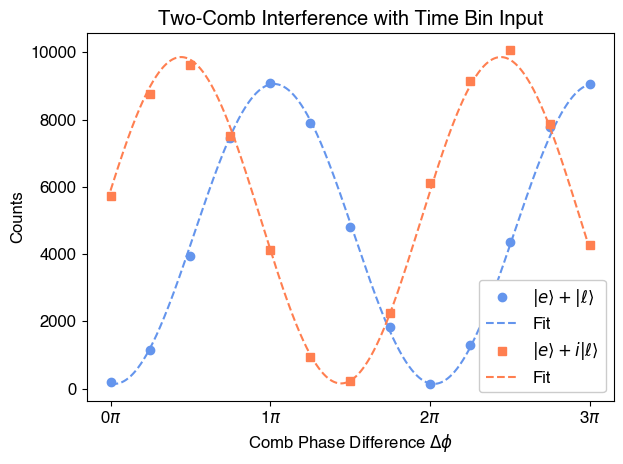

In [6]:
# plotting of points and fitted fringe for low power
x_points_for_eval = np.linspace(min(all_phases), max(all_phases), 1000)
plt.plot(all_phases, all_interference_counts,
         color=color_no_phase, ls='', marker='o',
         label=rf'$|e\rangle + |\ell\rangle$')
plt.plot(x_points_for_eval, res.eval(x=x_points_for_eval),
         color=color_no_phase, ls='--',
         label='Fit')
plt.plot(all_phases_phase, all_interference_counts_phase,
         color=color_phase, ls='', marker='s',
         label=rf'$|e\rangle + i|\ell\rangle$')
plt.plot(x_points_for_eval, res_phase.eval(x=x_points_for_eval),
         color=color_phase, ls='--',
         label='Fit')
plt.title('Two-Comb Interference with Time Bin Input')
plt.xlabel(r'Comb Phase Difference $\Delta\phi$')
plt.ylabel('Counts')
plt.legend(framealpha=1)

ax = plt.gca()
ax.xaxis.set_major_formatter(tck.FormatStrFormatter(r'%g$\pi$'))
ax.xaxis.set_major_locator(tck.MultipleLocator(base=1.0))

plt.tight_layout()
plt.show()

In [7]:
# get data for high power
df_min_high = pd.read_csv(data_min_high, sep='\t')
df_max_high = pd.read_csv(data_max_high, sep='\t')
df_min_phase_high = pd.read_csv(data_min_phase_high, sep='\t')
df_max_phase_high = pd.read_csv(data_max_phase_high, sep='\t')

time = df_min_high['time(ps)']  # assume all use same time
time /= 1e6  # convert to us
int_idx = np.where(np.logical_and(time > interference_window[0], time < interference_window[1]))[0]
min_int_counts = np.sum(df_min_high['counts'][int_idx])
max_int_counts = np.sum(df_max_high['counts'][int_idx])
fidelity_high = max_int_counts / (min_int_counts + max_int_counts)
min_int_counts_phase = np.sum(df_min_phase_high['counts'][int_idx])
max_int_counts_phase = np.sum(df_max_phase_high['counts'][int_idx])
fidelity_phase_high = max_int_counts_phase / (min_int_counts_phase + max_int_counts_phase)

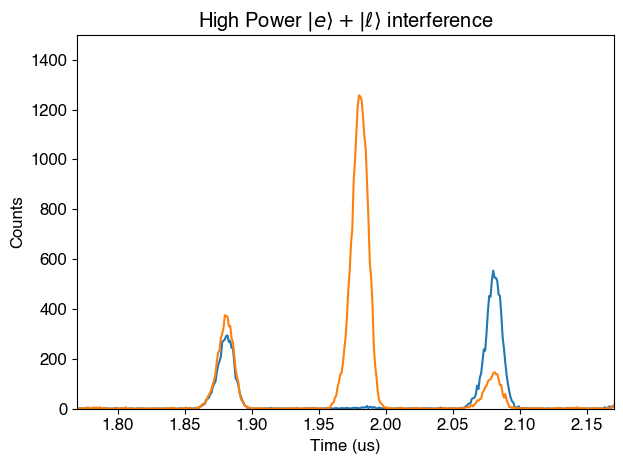

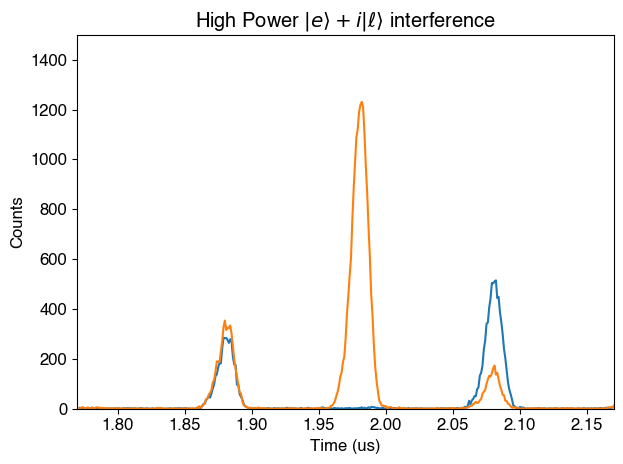

In [8]:
# plot high power
plt.plot(time, df_min_high['counts'])
plt.plot(time, df_max_high['counts'])
plt.xlabel('Time (us)')
plt.ylabel('Counts')
plt.title(r'High Power $|e\rangle + |\ell\rangle$ Interference')
plt.ylim(0, 1500)
plt.xlim(xlim)
plt.tight_layout()
plt.show()

plt.plot(time, df_min_phase_high['counts'])
plt.plot(time, df_max_phase_high['counts'])
plt.xlabel('Time (us)')
plt.ylabel('Counts')
plt.title(r'High Power $|e\rangle + i|\ell\rangle$ Interference')
plt.ylim(0, 1500)
plt.xlim(xlim)
plt.tight_layout()
plt.show()

# Calculating Error Rates

For a given input state $\psi$, the error rate is defined as
$$E_\psi = \frac{C_{\psi^\perp|\psi}}{C_{\psi^\perp|\psi} + C_{\psi|\psi}}$$